In [1]:
!git clone https://github.com/fastai/course-v3.git
!mv course-v3/nbs/dl2/exp . # Move the exp folder to your current directory

Cloning into 'course-v3'...
remote: Enumerating objects: 5909, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5909 (delta 9), reused 1 (delta 1), pack-reused 5893 (from 1)
Receiving objects: 100% (5909/5909), 263.04 MiB | 30.09 MiB/s, done.
Resolving deltas: 100% (3259/3259), done.


In [2]:
from exp.nb_08 import *

## Imagenette data
We grab the data from the previous notebook.

In [3]:
from fastai.data.external import untar_data, URLs
import pathlib

In [4]:
data_url = URLs.IMAGENETTE_160
path = untar_data(data_url)
path

<div><progress max="99003388" value="99008512"></progress> 100.01% [99008512/99003388 00:02&lt;00:00]</div>

Path('/root/.fastai/data/imagenette2-160')

In [5]:
list(path.ls())

[Path('/root/.fastai/data/imagenette2-160/noisy_imagenette.csv'),
 Path('/root/.fastai/data/imagenette2-160/.DS_Store'),
 Path('/root/.fastai/data/imagenette2-160/val'),
 Path('/root/.fastai/data/imagenette2-160/train')]

In [6]:
tfms = [make_rgb, ResizeFixed(128), to_byte_tensor, to_float_tensor]
bs=128

il = ImageList.from_files(path, tfms=tfms)
sd = SplitData.split_by_func(il, partial(grandparent_splitter, valid_name='val'))
ll = label_by_func(sd, parent_labeler, proc_y=CategoryProcessor())
data = ll.to_databunch(bs, c_in=3, c_out=10, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Then a model:

In [7]:
nfs = [32,64,128,256]

In [8]:
cbfs = [partial(AvgStatsCallback,accuracy), CudaCallback,
        partial(BatchTransformXCallback, norm_imagenette)]

This is the baseline of training with vanilla SGD.

In [9]:
learn,run = get_learn_run(nfs, data, 0.4, conv_layer, cbs=cbfs)

In [10]:
run.fit(1, learn)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only 

train: [1.7926112924411237, tensor(0.3819, device='cuda:0')]
valid: [1.7023449940286624, tensor(0.4464, device='cuda:0')]


## Refining the optimizer
In PyTorch, the base optimizer in `torch.optim` is just a dictionary that stores the hyper-parameters and references to the parameters of the model we want to train in parameter groups (different groups can have different learning rates/momentum/weight decay... which is what lets us do discriminative learning rates).

It contains a method `step` that will update our parameters with the gradients and a method `zero_grad` to detach and zero the gradients of all our parameters.

We build the equivalent from scratch, only ours will be more flexible. In our implementation, the step function loops over all the parameters to execute the step using stepper functions that we have to provide when initializing the optimizer.

In [11]:
class Optimizer():
    def __init__(self, params, steppers, **defaults):
        # might be a generator
        self.param_groups = list(params)
        # ensure params is a list of lists
        if not isinstance(self.param_groups[0], list): self.param_groups = [self.param_groups]
        self.hypers = [{**defaults} for p in self.param_groups]
        self.steppers = listify(steppers)

    def grad_params(self):
        return [(p,hyper) for pg,hyper in zip(self.param_groups,self.hypers)
            for p in pg if p.grad is not None]

    def zero_grad(self):
        for p,hyper in self.grad_params():
            p.grad.detach_()
            p.grad.zero_()

    def step(self):
        for p,hyper in self.grad_params(): compose(p, self.steppers, **hyper)

Note: our step fn isn't actually going to do anything, it's going to use composition on some things that we pass on and ask them to do something - so this optimizer is going to do nothing at all until we build on top of it.

Going to set it up to handle things such as:
- discriminitive learning rates
- one cycle annealing
- etc

to be able to do that, we need some way to create parameter groups (layer groups in fastai)

recall our first linear layer we created, parameters in pytorch:
- weight tensor & bias tensor - each of which is a parameter tensor

in order to optimize something we need to know what all the parameter tensors are in a model

can just say: `model.parameters()` to grab them all in pytorch:
- In PyTorch, `model.parameters()` is a method that returns an iterator over all the learnable parameters (weights and biases) of a neural network
- that's going to turn it into a generator, but as soon as you call `list()` on a generator it turns it into an actual list -> list of all the tensors (w&b)

To do basic SGD, this what a step looks like:

In [12]:
#export
def sgd_step(p, lr, **kwargs):
    p.data.add_(-lr, p.grad.data)
    return p

In [13]:
opt_func = partial(Optimizer, steppers=[sgd_step])

Now that we have changed the optimizer, we will need to adjust the callbacks that were using properties from the PyTorch optimizer: in particular the hyper-parameters are in the list of dictionaries `opt.hypers` (PyTorch has everything in the the list of param groups).

In [14]:
#export
class Recorder(Callback):
    def begin_fit(self): self.lrs,self.losses = [],[]

    def after_batch(self):
        if not self.in_train: return
        self.lrs.append(self.opt.hypers[-1]['lr'])
        self.losses.append(self.loss.detach().cpu())

    def plot_lr  (self): plt.plot(self.lrs)
    def plot_loss(self): plt.plot(self.losses)

    def plot(self, skip_last=0):
        losses = [o.item() for o in self.losses]
        n = len(losses)-skip_last
        plt.xscale('log')
        plt.plot(self.lrs[:n], losses[:n])

class ParamScheduler(Callback):
    _order=1
    def __init__(self, pname, sched_funcs):
        self.pname,self.sched_funcs = pname,listify(sched_funcs)

    def begin_batch(self):
        if not self.in_train: return
        fs = self.sched_funcs
        if len(fs)==1: fs = fs*len(self.opt.param_groups)
        pos = self.n_epochs/self.epochs
        for f,h in zip(fs,self.opt.hypers): h[self.pname] = f(pos)

class LR_Find(Callback):
    _order=1
    def __init__(self, max_iter=100, min_lr=1e-6, max_lr=10):
        self.max_iter,self.min_lr,self.max_lr = max_iter,min_lr,max_lr
        self.best_loss = 1e9

    def begin_batch(self):
        if not self.in_train: return
        pos = self.n_iter/self.max_iter
        lr = self.min_lr * (self.max_lr/self.min_lr) ** pos
        for pg in self.opt.hypers: pg['lr'] = lr

    def after_step(self):
        if self.n_iter>=self.max_iter or self.loss>self.best_loss*10:
            raise CancelTrainException()
        if self.loss < self.best_loss: self.best_loss = self.loss

So let's check we didn't break anything and that recorder and param scheduler work properly.

In [15]:
sched = combine_scheds([0.3, 0.7], [sched_cos(0.3, 0.6), sched_cos(0.6, 0.2)])

In [16]:
cbfs = [partial(AvgStatsCallback,accuracy),
        CudaCallback, Recorder,
        partial(ParamScheduler, 'lr', sched)]

In [17]:
learn,run = get_learn_run(nfs, data, 0.4, conv_layer, cbs=cbfs, opt_func=opt_func)

In [18]:
%time run.fit(1, learn)

/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.7906080450021122, tensor(0.3903, device='cuda:0')]
valid: [1.4742607981687899, tensor(0.5139, device='cuda:0')]
CPU times: user 2 s, sys: 799 ms, total: 2.8 s
Wall time: 15.1 s


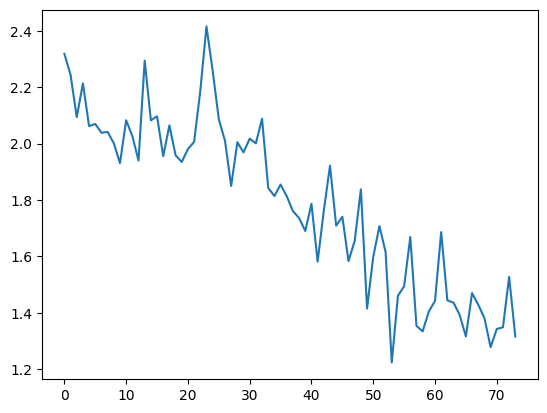

In [19]:
run.recorder.plot_loss()

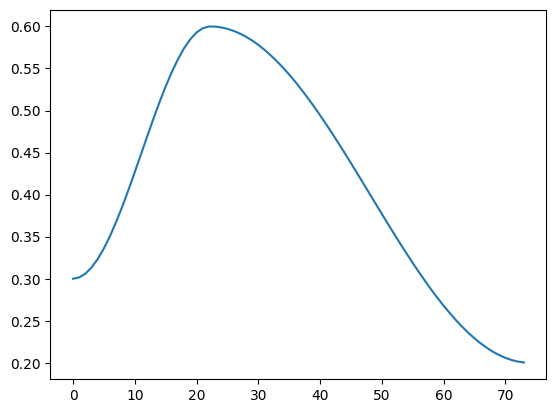

In [20]:
run.recorder.plot_lr()

## Weight decay
By letting our model learn high parameters, it might fit all the data points in the training set with an over-complex function that has very sharp changes, which will lead to overfitting.

In [21]:
#export
def weight_decay(p, lr, wd, **kwargs):
    p.data.mul_(1 - lr*wd)
    return p
weight_decay._defaults = dict(wd=0.)

L2 regularization is adding `wd*weight` to the gradients.

In [22]:
#export
def l2_reg(p, lr, wd, **kwargs):
    p.grad.data.add_(wd, p.data)
    return p
l2_reg._defaults = dict(wd=0.)

Let's allow steppers to add to our `defaults` (which are the default values of all the hyper-parameters).  
This helper function adds in `dest` the key/values it finds while going through `os` and applying `f` when they was no `key` of the same name.

In [23]:
#export
def maybe_update(os, dest, f):
    for o in os:
        for k,v in f(o).items():
            if k not in dest: dest[k] = v

def get_defaults(d): return getattr(d,'_defaults',{})

This is the same as before, we just take the default values of the steppers when none are provided in the kwargs.

In [24]:
#export
class Optimizer():
    def __init__(self, params, steppers, **defaults):
        self.steppers = listify(steppers)
        maybe_update(self.steppers, defaults, get_defaults)
        # might be a generator
        self.param_groups = list(params)
        # ensure params is a list of lists
        if not isinstance(self.param_groups[0], list): self.param_groups = [self.param_groups]
        self.hypers = [{**defaults} for p in self.param_groups]

    def grad_params(self):
        return [(p,hyper) for pg,hyper in zip(self.param_groups,self.hypers)
            for p in pg if p.grad is not None]

    def zero_grad(self):
        for p,hyper in self.grad_params():
            p.grad.detach_()
            p.grad.zero_()

    def step(self):
        for p,hyper in self.grad_params(): compose(p, self.steppers, **hyper)

In [25]:
#export
sgd_opt = partial(Optimizer, steppers=[weight_decay, sgd_step])

In [26]:
learn,run = get_learn_run(nfs, data, 0.4, conv_layer, cbs=cbfs, opt_func=sgd_opt)

Before trying to train, let's check the behavior works as intended: when we don't provide a value for `wd`, we pull the corresponding default from `weight_decay`.

In [27]:
model = learn.model

In [28]:
opt = sgd_opt(model.parameters(), lr=0.1)
test_eq(opt.hypers[0]['wd'], 0.)
test_eq(opt.hypers[0]['lr'], 0.1)

But if we provide a value, it overrides the default.

In [29]:
opt = sgd_opt(model.parameters(), lr=0.1, wd=1e-4)
test_eq(opt.hypers[0]['wd'], 1e-4)
test_eq(opt.hypers[0]['lr'], 0.1)

Now let's fit.

In [30]:
cbfs = [partial(AvgStatsCallback,accuracy), CudaCallback]

In [31]:
learn,run = get_learn_run(nfs, data, 0.3, conv_layer, cbs=cbfs, opt_func=partial(sgd_opt, wd=0.01))

In [32]:
run.fit(1, learn)

/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.7846211981201816, tensor(0.3779, device='cuda:0')]
valid: [1.891197004378981, tensor(0.3345, device='cuda:0')]


This is already better than the baseline!

## With momentum
Momentum requires to add some state. We need to save the moving average of the gradients to be able to do the step and store this inside the optimizer state.  
To do this, we introduce statistics. Statistics are object with two methods:

- `init_state`, that returns the initial state (a tensor of 0. for the moving average of gradients)
- `update`, that updates the state with the new gradient value

We also read the `_defaults` values of those objects, to allow them to provide default values to hyper-parameters.

In [33]:
#export
class StatefulOptimizer(Optimizer):
    def __init__(self, params, steppers, stats=None, **defaults):
        self.stats = listify(stats)
        maybe_update(self.stats, defaults, get_defaults)
        super().__init__(params, steppers, **defaults)
        self.state = {}

    def step(self):
        for p,hyper in self.grad_params():
            if p not in self.state:
                #Create a state for p and call all the statistics to initialize it.
                self.state[p] = {}
                maybe_update(self.stats, self.state[p], lambda o: o.init_state(p))
            state = self.state[p]
            for stat in self.stats: state = stat.update(p, state, **hyper)
            compose(p, self.steppers, **state, **hyper)
            self.state[p] = state

In [34]:
#export
class Stat():
    _defaults = {}
    def init_state(self, p): raise NotImplementedError
    def update(self, p, state, **kwargs): raise NotImplementedError

Here is an example of `Stat`:

In [35]:
class AverageGrad(Stat):
    _defaults = dict(mom=0.9)

    def init_state(self, p): return {'grad_avg': torch.zeros_like(p.grad.data)}
    def update(self, p, state, mom, **kwargs):
        state['grad_avg'].mul_(mom).add_(p.grad.data)
        return state

Then we add the momentum step (instead of using the gradients to perform the step, we use the average).

In [36]:
#export
def momentum_step(p, lr, grad_avg, **kwargs):
    p.data.add_(-lr, grad_avg)
    return p

In [37]:
sgd_mom_opt = partial(StatefulOptimizer, steppers=[momentum_step,weight_decay],
                  stats=AverageGrad(), wd=0.01)

In [38]:
learn,run = get_learn_run(nfs, data, 0.3, conv_layer, cbs=cbfs, opt_func=sgd_mom_opt)

In [39]:
run.fit(1, learn)

/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [2.0340550001980144, tensor(0.3329, device='cuda:0')]
valid: [1.8529694964171974, tensor(0.3633, device='cuda:0')]


## Momentum experiments
What does momentum do to the gradients exactly? Let's do some plots to find out!

In [40]:
x = torch.linspace(-4, 4, 200)
y = torch.randn(200) + 0.3
betas = [0.5, 0.7, 0.9, 0.99]

In [41]:
def plot_mom(f):
    _,axs = plt.subplots(2,2, figsize=(12,8))
    for beta,ax in zip(betas, axs.flatten()):
        ax.plot(y, linestyle='None', marker='.')
        avg,res = None,[]
        for i,yi in enumerate(y):
            avg,p = f(avg, beta, yi, i)
            res.append(p)
        ax.plot(res, color='red')
        ax.set_title(f'beta={beta}')

This is the regular momentum.

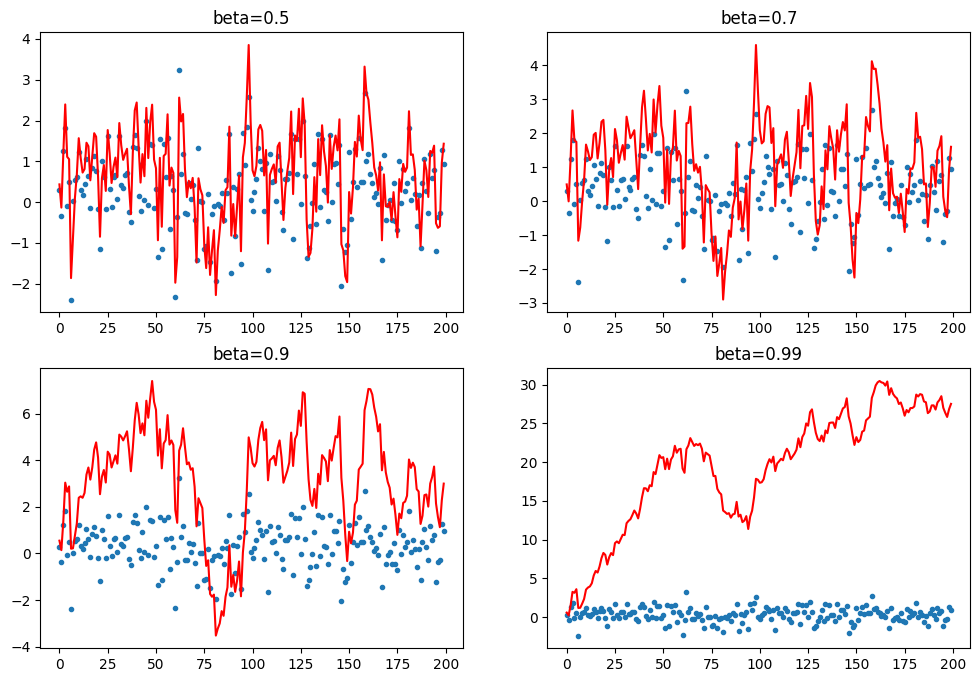

In [42]:
def mom1(avg, beta, yi, i):
    if avg is None: avg=yi
    res = beta*avg + yi
    return res,res
plot_mom(mom1)

As we can see, with a too high value, it may go way too high with no way to change its course.

Another way to smooth noisy data is to do an exponentially weighted moving average. In this case, there is a dampening of (1-beta) in front of the new value, which is less trusted than the current average. We'll define `lin_comb` (linear combination) to make this easier (note that in the lesson this was named `ewma`).

In [43]:
#export
def lin_comb(v1, v2, beta): return beta*v1 + (1-beta)*v2

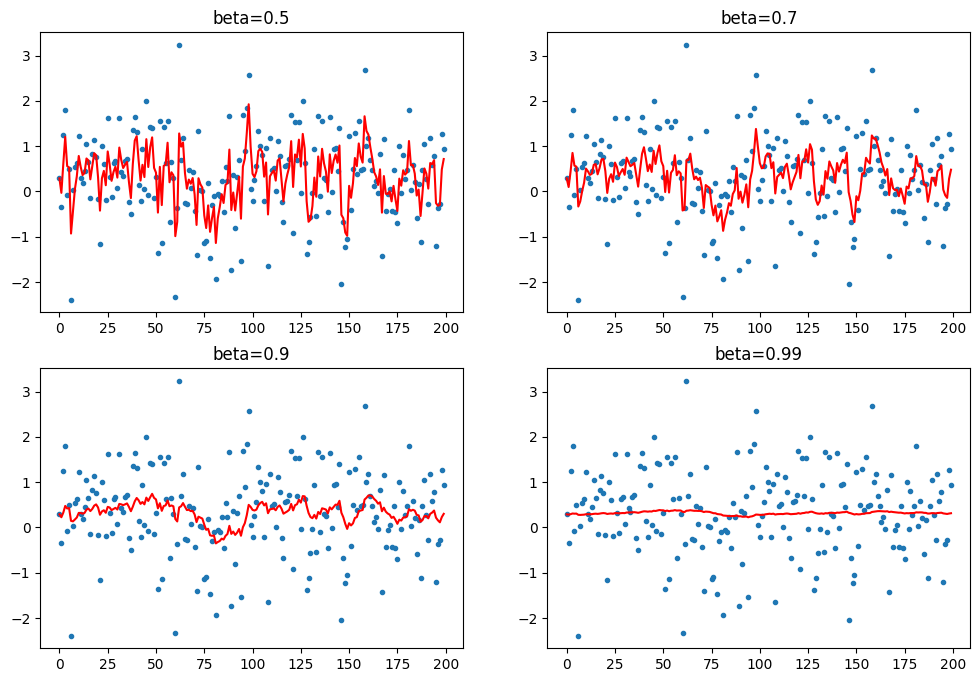

In [44]:
def mom2(avg, beta, yi, i):
    if avg is None: avg=yi
    avg = lin_comb(avg, yi, beta)
    return avg, avg
plot_mom(mom2)

We can see it gets to a zero-constant when the data is purely random. If the data has a certain shape, it will get that shape (with some delay for high beta).

In [45]:
y = 1 - (x/3) ** 2 + torch.randn(200) * 0.1

In [46]:
y[0]=0.5

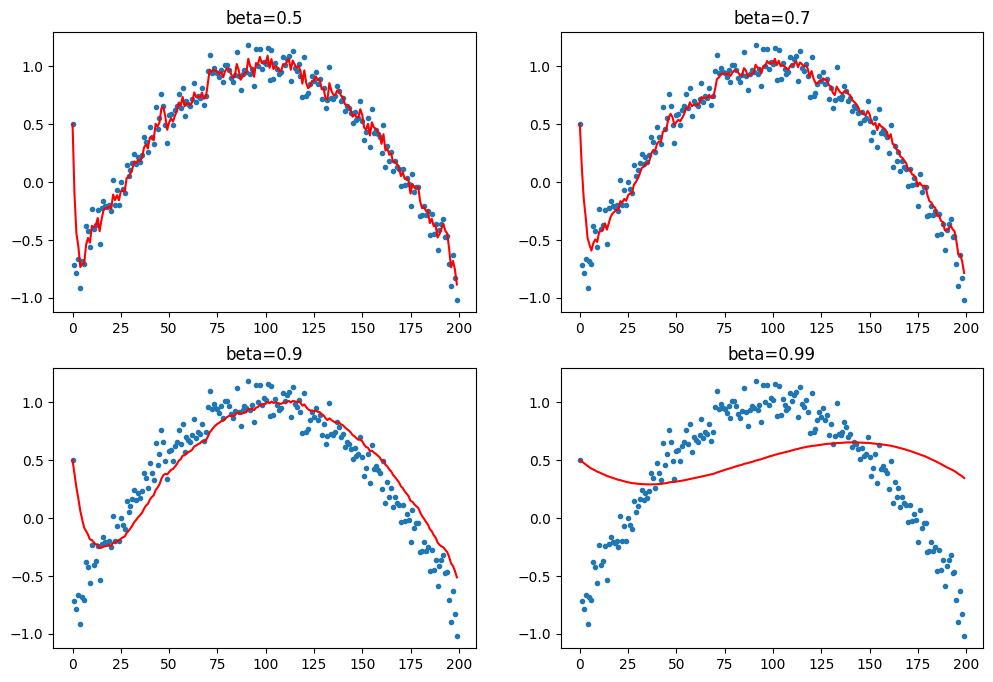

In [47]:
plot_mom(mom2)

Debiasing is here to correct the wrong information we may have in the very first batch. The debias term corresponds to the sum of the coefficient in our moving average.


By dividing by this term, we make our moving average a true average (in the sense that all the coefficients we used for the average sum up to 1).

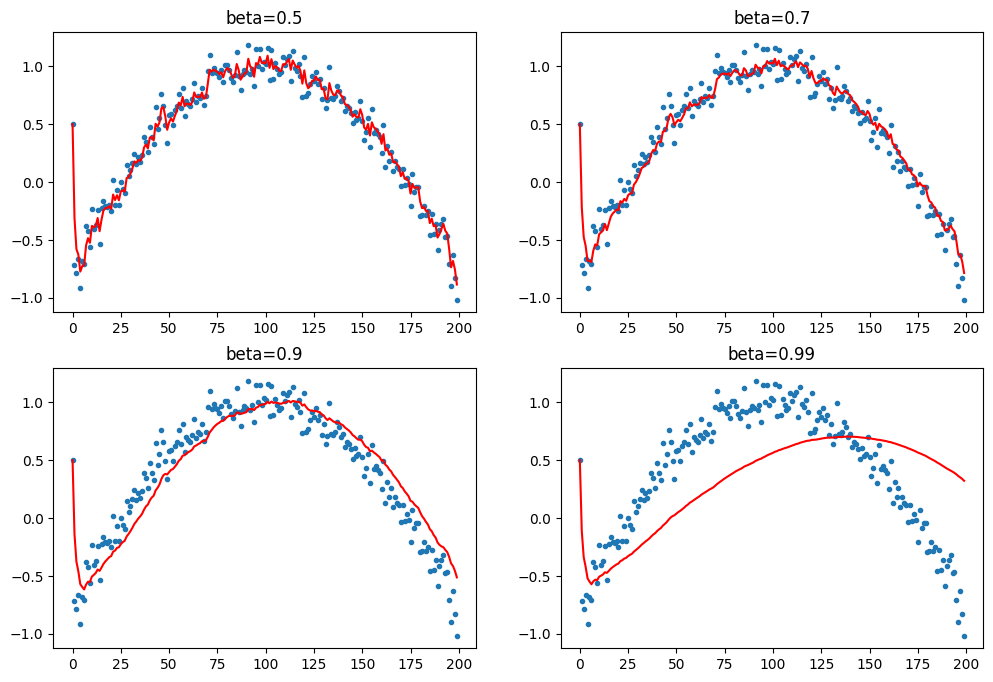

In [48]:
def mom3(avg, beta, yi, i):
    if avg is None: avg=0
    avg = lin_comb(avg, yi, beta)
    return avg, avg/(1-beta**(i+1))
plot_mom(mom3)

## Adam and friends
In Adam, we use the gradient averages but with dampening (not like in SGD with momentum), so let's add this to the `AverageGrad` class.

In [49]:
#export
class AverageGrad(Stat):
    _defaults = dict(mom=0.9)

    def __init__(self, dampening:bool=False): self.dampening=dampening
    def init_state(self, p): return {'grad_avg': torch.zeros_like(p.grad.data)}
    def update(self, p, state, mom, **kwargs):
        state['mom_damp'] = 1-mom if self.dampening else 1.
        state['grad_avg'].mul_(mom).add_(state['mom_damp'], p.grad.data)
        return state

We also need to track the moving average of the gradients squared.

In [50]:
#export
class AverageSqrGrad(Stat):
    _defaults = dict(sqr_mom=0.99)

    def __init__(self, dampening:bool=True): self.dampening=dampening
    def init_state(self, p): return {'sqr_avg': torch.zeros_like(p.grad.data)}
    def update(self, p, state, sqr_mom, **kwargs):
        state['sqr_damp'] = 1-sqr_mom if self.dampening else 1.
        state['sqr_avg'].mul_(sqr_mom).addcmul_(state['sqr_damp'], p.grad.data, p.grad.data)
        return state

We will also need the number of steps done during training for the debiasing.

In [51]:
#export
class StepCount(Stat):
    def init_state(self, p): return {'step': 0}
    def update(self, p, state, **kwargs):
        state['step'] += 1
        return state

This helper function computes the debias term. If we dampening, `damp = 1 - mom` and we get the same result as before. If we don't use dampening, (`damp = 1`) we will need to divide by `1 - mom` because that term is missing everywhere.

In [52]:
#export
def debias(mom, damp, step): return damp * (1 - mom**step) / (1-mom)

Then the Adam step is just the following:

In [53]:
#export
def adam_step(p, lr, mom, mom_damp, step, sqr_mom, sqr_damp, grad_avg, sqr_avg, eps, **kwargs):
    debias1 = debias(mom,     mom_damp, step)
    debias2 = debias(sqr_mom, sqr_damp, step)
    p.data.addcdiv_(-lr / debias1, grad_avg, (sqr_avg/debias2).sqrt() + eps)
    return p
adam_step._defaults = dict(eps=1e-5)

In [54]:
#export
def adam_opt(xtra_step=None, **kwargs):
    return partial(StatefulOptimizer, steppers=[adam_step,weight_decay]+listify(xtra_step),
                   stats=[AverageGrad(dampening=True), AverageSqrGrad(), StepCount()], **kwargs)

In [55]:
learn,run = get_learn_run(nfs, data, 0.001, conv_layer, cbs=cbfs, opt_func=adam_opt())

In [56]:
run.fit(3, learn)

/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.7548934351568275, tensor(0.3970, device='cuda:0')]
valid: [1.5679901472929936, tensor(0.4785, device='cuda:0')]


/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.2418146756851305, tensor(0.5906, device='cuda:0')]
valid: [1.3577843849522293, tensor(0.5595, device='cuda:0')]


/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [0.9391139219096526, tensor(0.7017, device='cuda:0')]
valid: [1.247841859076433, tensor(0.5941, device='cuda:0')]


## LAMB
It's then super easy to implement a new optimizer. This is LAMB from a very recent paper:

In [57]:
def lamb_step(p, lr, mom, mom_damp, step, sqr_mom, sqr_damp, grad_avg, sqr_avg, eps, wd, **kwargs):
    debias1 = debias(mom,     mom_damp, step)
    debias2 = debias(sqr_mom, sqr_damp, step)
    r1 = p.data.pow(2).mean().sqrt()
    step = (grad_avg/debias1) / ((sqr_avg/debias2).sqrt()+eps) + wd*p.data
    r2 = step.pow(2).mean().sqrt()
    p.data.add_(-lr * min(r1/r2,10), step)
    return p
lamb_step._defaults = dict(eps=1e-6, wd=0.)

In [58]:
lamb = partial(StatefulOptimizer, steppers=lamb_step, stats=[AverageGrad(dampening=True), AverageSqrGrad(), StepCount()])

In [59]:
learn,run = get_learn_run(nfs, data, 0.003, conv_layer, cbs=cbfs, opt_func=lamb)

In [60]:
run.fit(3, learn)

/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.8400399081872425, tensor(0.3597, device='cuda:0')]
valid: [1.5783733081210192, tensor(0.4741, device='cuda:0')]


/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.326429397078625, tensor(0.5650, device='cuda:0')]
valid: [1.4663267565684714, tensor(0.5243, device='cuda:0')]


/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  res = torch.ByteTensor(torch.ByteStorage.from_buffer(item.tobytes()))
/content/exp/nb_08.py:172: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access Un

train: [1.0267603289352096, tensor(0.6682, device='cuda:0')]
valid: [1.2653513136942676, tensor(0.5898, device='cuda:0')]


Other recent variants of optimizers:

- Large Batch Training of Convolutional Networks (LARS also uses weight statistics, not just gradient statistics. Can you add that to this class?)
- Adafactor: Adaptive Learning Rates with Sublinear Memory Cost (Adafactor combines stats over multiple sets of axes)
- Adaptive Gradient Methods with Dynamic Bound of Learning Rate